<a href="https://colab.research.google.com/github/gabrieldanho9988-sys/SAR-Super-Resolution-Using-AI/blob/main/Project_Synthetic_Aperture_Radar_(SAR)_Super_Resolution_(SR)_using_AI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Environment & Data Discovery (Installs, API connections)

In [1]:
!pip install pystac stac-asset[cli] rasterio
import pystac

collection = pystac.Collection.from_file(
    "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
)

# Check first item to see available properties
print("Available properties for the first item:")
for i, item in enumerate(collection.get_items()):
    if i == 0:
        for key, value in item.properties.items():
            print(f"  {key}: {value}")
        print("\nAvailable assets:")
        for key in item.assets.keys():
            print(f"  {key}")
        break

INFO: pip is looking at multiple versions of rasterio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 52.5 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Attempting uninstall: rasterio
    Found existing installation: rasterio 1.5.0
    Uninstalling rasterio-1.5.0:
      Successfully uninstalled rasterio-1.5.0
Available properties for the first item:
  proj:centroid: {'lon': -155.286900345, 'lat': 19.421037849999998}
  proj:shape: [46671, 51171]
  proj:trans

# 2.1 Define STAC Metadata Extraction Function

In [2]:
import pystac
from multiprocessing import Pool, cpu_count

def process_item(item_link):
    """Process a single item and extract key parameters"""
    try:
        item = pystac.Item.from_file(item_link)
        props = item.properties

        # Get centroid from proj:centroid if available
        centroid = props.get('proj:centroid', {})

        # Return the original item_link, item_id, and the extracted properties dictionary
        return (
            item_link,
            item.id,
            {
                'stac_id': item.id,
                'collect_id': props.get('capella:collect_id', ''),
                'datetime': props.get('datetime', ''),
                'start_datetime': props.get('start_datetime', ''),
                'end_datetime': props.get('end_datetime', ''),
                'center_lon': centroid.get('lon', ''),
                'center_lat': centroid.get('lat', ''),
                'platform': props.get('platform', ''),
                'constellation': props.get('constellation', ''),
                'instrument_mode': props.get('sar:instrument_mode', ''),
                'frequency_band': props.get('sar:frequency_band', ''),
                'center_frequency': props.get('sar:center_frequency', ''),
                'polarizations': ','.join(props.get('sar:polarizations', [])),
                'orbit_state': props.get('sat:orbit_state', ''),
                'product_type': props.get('sar:product_type', ''),
                'observation_direction': props.get('sar:observation_direction', ''),
                'incidence_angle': props.get('view:incidence_angle', ''),
                'azimuth': props.get('view:azimuth', ''),
                'squint_angle': props.get('capella:squint_angle', ''),
                'layover_angle': props.get('capella:layover_angle', ''),
                'look_angle': props.get('capella:look_angle', ''),
                'resolution_range': props.get('sar:resolution_range', ''),
                'resolution_azimuth': props.get('sar:resolution_azimuth', ''),
                'resolution_ground_range': props.get('capella:resolution_ground_range', ''),
                'pixel_spacing_range': props.get('sar:pixel_spacing_range', ''),
                'pixel_spacing_azimuth': props.get('sar:pixel_spacing_azimuth', ''),
                'image_length': props.get('capella:image_length', ''),
                'image_width': props.get('capella:image_width', ''),
                'looks_range': props.get('sar:looks_range', ''),
                'looks_azimuth': props.get('sar:looks_azimuth', ''),
                'orbital_plane': props.get('capella:orbital_plane', ''),
                'collection_type': props.get('capella:collection_type', ''),
            }
        )
    except Exception as e:
        print(f"Error processing {item_link}: {e}")
        return None, None, None # Return None for all if error

# 2.2 Retrieve STAC Item Links

In [3]:
from urllib.parse import urljoin

# Open collection
print("Opening collection...")
collection_url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
collection = pystac.Collection.from_file(collection_url)

# Get item links and resolve relative URLs
print("Collecting item links...")
item_links = []
stac_id_to_href_map = {}

for link in collection.links:
    if link.rel == 'item':
        # Resolve relative path to absolute URL
        absolute_url = link.absolute_href # pystac can resolve this for us
        item_links.append(absolute_url)

print(f"Found {len(item_links)} items")
print(f"Example URL: {item_links[0]}") # Check if it looks right

Opening collection...
Found 1582 items
Example URL: https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-by-datetime/capella-open-data-2025/capella-open-data-2025-11/capella-open-data-2025-11-12/CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453/CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453.json


# 2.3 Execute Parallel Metadata Extraction

In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Process with threading
print(f"Processing with {cpu_count()} threads...")
all_processed_item_data = [] # Stores dictionaries of properties
# Use cpu_count() for the number of workers for multiprocessing
# This ensures a reasonable number of processes are used.

with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
    futures = [executor.submit(process_item, link) for link in item_links]

    for future in tqdm(as_completed(futures), total=len(futures)):
        item_link, stac_id, item_props = future.result()
        if item_props:
            all_processed_item_data.append(item_props)
            stac_id_to_href_map[stac_id] = item_link # Build the map here

Processing with 2 threads...


100%|██████████| 1582/1582 [02:06<00:00, 12.52it/s]


# 2.4 Export Metadata to CSV

In [5]:
import csv

filename = "Capella_IEEE_DataContest_2026.csv"
if all_processed_item_data:
    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=all_processed_item_data[0].keys())
        writer.writeheader()
        writer.writerows(all_processed_item_data)
    print(f"Saved metadata to {filename}")

Saved metadata to Capella_IEEE_DataContest_2026.csv


# 3.1 Spatiotemporal Filtering (Targeting Los Angeles)

In [6]:
import pandas as pd
from datetime import datetime, timezone
from tabulate import tabulate

# Load the CSV
df_metadata = pd.read_csv(filename)

# Convert datetime columns to pandas datetime
df_metadata['datetime'] = pd.to_datetime(df_metadata['datetime'])
df_metadata['start_datetime'] = pd.to_datetime(df_metadata['start_datetime'])
df_metadata['end_datetime'] = pd.to_datetime(df_metadata['end_datetime'])

# Define time range (e.g., from 2020 to now)
start_time = datetime(2020, 1, 1, tzinfo=timezone.utc)
end_time = datetime.now(timezone.utc)

# Define Los Angeles bounding box (approximate)
la_bbox = {
    'west': -118.7,
    'east': -117.7,
    'south': 33.7,
    'north': 34.4
}

# Filter by time and location
filtered_df = df_metadata[
    (df_metadata['start_datetime'] >= start_time) &
    (df_metadata['start_datetime'] <= end_time) &
    (df_metadata['center_lon'] >= la_bbox['west']) &
    (df_metadata['center_lon'] <= la_bbox['east']) &
    (df_metadata['center_lat'] >= la_bbox['south']) &
    (df_metadata['center_lat'] <= la_bbox['north'])
].copy() # Use .copy() to avoid SettingWithCopyWarning

print(f"Found {len(filtered_df)} items over Los Angeles after filtering.")
if not filtered_df.empty:
    print(f"Date range: {filtered_df['start_datetime'].min()} to {filtered_df['start_datetime'].max()}")

    print("\nFiltered items (first 5 rows):")
    print(tabulate(
        filtered_df[['stac_id', 'datetime', 'center_lon', 'center_lat', 'instrument_mode']].head(5),
        headers='keys',
        tablefmt='grid',
        showindex=False
    ))
    # Save to new CSV
    filtered_df.to_csv("capella_la_filtered.csv", index=False)
    print("\nSaved filtered metadata to capella_la_filtered.csv")
else:
    print("No items found after filtering by time and location.")

Found 8 items over Los Angeles after filtering.
Date range: 2024-12-11 09:47:26.904082+00:00 to 2025-09-02 02:11:14.960155+00:00

Filtered items (first 5 rows):
+-----------------------------------------------------+----------------------------------+--------------+--------------+-------------------+
| stac_id                                             | datetime                         |   center_lon |   center_lat | instrument_mode   |
+=====================================================+==================================+==============+==============+===================+
| CAPELLA_C13_SP_SLC_HH_20250902021114_20250902021153 | 2025-09-02 02:11:34.236420+00:00 |      -118.24 |      34.0735 | spotlight         |
+-----------------------------------------------------+----------------------------------+--------------+--------------+-------------------+
| CAPELLA_C13_SP_GEO_HH_20250902021114_20250902021153 | 2025-09-02 02:11:34.236661+00:00 |      -118.24 |      34.0732 | spotlight    

# 3.2 Setup Image Processing & SAR Normalization Function


Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_SLC_HH_20250902021114_20250902021153.tif
Full image shape is: 118657x15337
Extracted patch max value: (105-45j)

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_GEO_HH_20250902021114_20250902021153.tif
Full image shape is: 45297x45119
Extracted patch max value: 1415

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_SLC_HH_20250830031430_20250830031509.tif
Full image shape is: 118646x15337
Extracted patch max value: (118+10j)

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_GEO_HH_20250830031430_20250830031509.tif
F

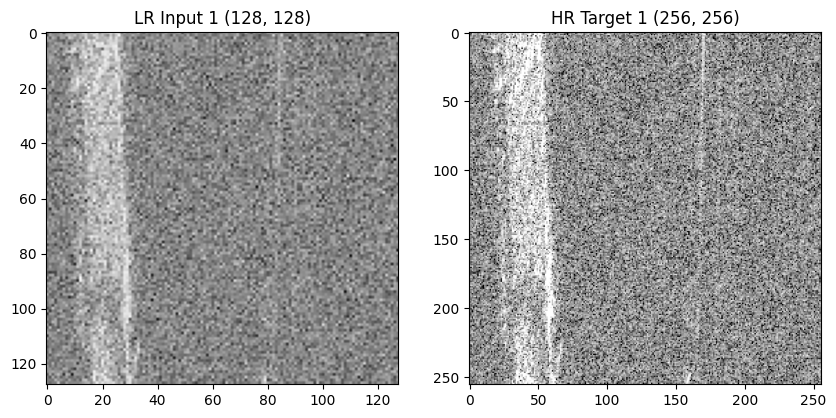

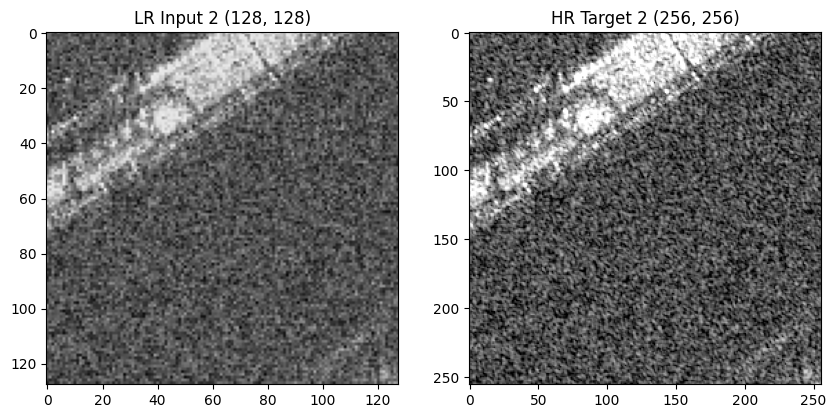

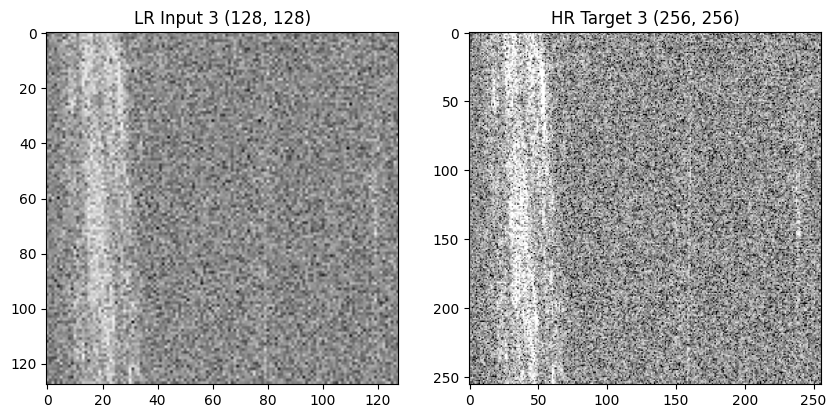

In [8]:
!pip install pystac stac-asset[cli] rasterio opencv-python matplotlib numpy nest-asyncio
import os
import pystac
import stac_asset.blocking
import rasterio
from rasterio.windows import Window # Import Window
import numpy as np
import cv2
import matplotlib.pyplot as plt
import nest_asyncio

# 1. Fix the asyncio error in Colab
nest_asyncio.apply()


def preprocess_sar_image(raw_dn, scale_factor=0.00063784):
    # Convert complex data to magnitude (absolute value) first
    # if it's complex, otherwise np.abs does nothing
    raw_dn_magnitude = np.abs(raw_dn)
    epsilon = 1e-10
    dn_scaled = (raw_dn_magnitude * scale_factor) + epsilon
    image_db = 20 * np.log10(dn_scaled)

    db_min, db_max = np.percentile(image_db, 2), np.percentile(image_db, 98)

    # Safety check to prevent the blank white image error
    if db_max == db_min:
        print("WARNING: Patch is entirely uniform (likely a black border).")
        return np.zeros_like(image_db)

    image_normalized = np.clip((image_db - db_min) / (db_max - db_min), 0, 1)
    return image_normalized

def create_hr_lr_pairs(hr_image, scale_factor_down=2):
    h, w = hr_image.shape
    new_h, new_w = h // scale_factor_down, w // scale_factor_down
    lr_image = cv2.resize(hr_image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return hr_image, lr_image


# The collection and item link filtering is now handled by the preceding cells,
# which produce `filtered_df` and `stac_id_to_href_map`.

# 2. Use the filtered items to get the hrefs for downloading
if filtered_df.empty:
    raise ValueError("No items found in filtered_df to download.")

# Define how many of the filtered images you want to actually download and process
MAX_IMAGES_TO_PROCESS = 8 # <--- Increased to 8 for more diverse data

geo_item_hrefs = []
for stac_id in filtered_df['stac_id'].unique():
    if stac_id in stac_id_to_href_map:
        geo_item_hrefs.append(stac_id_to_href_map[stac_id])
    if len(geo_item_hrefs) >= MAX_IMAGES_TO_PROCESS:
        break

if not geo_item_hrefs:
    raise ValueError("No image hrefs found from the filtered metadata.")

all_hr_targets = []
all_lr_inputs = []

os.makedirs("capella_data", exist_ok=True)

for i, geo_item_link in enumerate(geo_item_hrefs):
    print(f"\nDownloading GEO Item {i+1}/{len(geo_item_hrefs)}: {geo_item_link}")
    item = pystac.Item.from_file(geo_item_link)

    # 3. Filter out 'preview' and 'thumbnail' to get the REAL data asset
    asset_key_to_download = None
    for key, asset in item.assets.items():
        if asset.href.endswith('.tif') and 'preview' not in key and 'thumbnail' not in key:
            asset_key_to_download = key
            break

    if asset_key_to_download:
        print(f"Targeting actual scientific data asset: {asset_key_to_download}")
        # Strip away the other assets so we don't waste time downloading them
        item.assets = {asset_key_to_download: item.assets[asset_key_to_download]}

    # 4. Download using the correct keyword 'directory'
    print("Downloading... (This might take a minute depending on file size)")
    downloaded_item = stac_asset.blocking.download_item(item, directory="capella_data")

    # Find the downloaded .tif file
    tif_path = None
    # The downloaded item object itself has a 'assets' attribute pointing to local files
    for key, asset in downloaded_item.assets.items():
        if asset.href.endswith('.tif'):
            tif_path = asset.href # This will be the local path
            break

    if tif_path is None:
        print(f"WARNING: Could not find downloaded TIF for item {geo_item_link}. Skipping.")
        continue

    try:
        # 5. Preprocessing Functions (already defined)

        # 6. Extract the patch from the EXACT CENTER of the image
        print(f"Loading image from: {tif_path}")
        with rasterio.open(tif_path) as src:
            height, width = src.shape
            print(f"Full image shape is: {height}x{width}")

            # Find the middle coordinates
            center_y, center_x = height // 2, width // 2
            patch_size_px = 256 # Define the actual size of the patch (width and height)

            # Calculate window for reading
            row_start = center_y - patch_size_px // 2
            col_start = center_x - patch_size_px // 2

            # Ensure window is within image boundaries
            row_start = max(0, row_start)
            col_start = max(0, col_start)

            window = Window(col_start, row_start, patch_size_px, patch_size_px)

            # Read only the specified window to save RAM
            # rasterio.read(window=...) will return a 3D array (bands, height, width)
            # We want the first band, so [0, :, :]
            real_raw_sar = src.read(1, window=window)

            if real_raw_sar.shape[0] < patch_size_px or real_raw_sar.shape[1] < patch_size_px:
                print(f"WARNING: Extracted patch for item {geo_item_link} is smaller than requested ({patch_size_px}x{patch_size_px}) due to image boundary. Actual size: {real_raw_sar.shape[0]}x{real_raw_sar.shape[1]}.")

            print(f"Extracted patch max value: {np.max(real_raw_sar)}")

        hr_target_single = preprocess_sar_image(real_raw_sar)
        hr_target_single, lr_input_single = create_hr_lr_pairs(hr_target_single, scale_factor_down=2)

        all_hr_targets.append(hr_target_single)
        all_lr_inputs.append(lr_input_single)
    except Exception as e:
        print(f"ERROR processing image {tif_path}: {e}. Skipping this image.")
        # Optionally clean up the failed download to save disk space
        if os.path.exists(tif_path):
            os.remove(tif_path)

# Combine all patches into single NumPy arrays
if all_hr_targets and all_lr_inputs:
    hr_target = np.array(all_hr_targets) # Now hr_target will be (N_images, H, W)
    lr_input = np.array(all_lr_inputs)   # Now lr_input will be (N_images, H/2, W/2)
    print(f"\nSuccessfully processed {len(all_hr_targets)} images.")
    print(f"Combined HR Target shape: {hr_target.shape}")
    print(f"Combined LR Input shape: {lr_input.shape}")

    # 7. Plotting multiple pairs for visualization
    if len(all_hr_targets) > 0:
        num_plots = min(len(all_hr_targets), 3) # Plot up to 3 images
        for k in range(num_plots):
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.title(f"LR Input {k+1} {lr_input[k].shape}")
            plt.imshow(lr_input[k], cmap='gray')
            plt.subplot(1, 2, 2)
            plt.title(f"HR Target {k+1} {hr_target[k].shape}")
            plt.imshow(hr_target[k], cmap='gray')
            plt.show()

else:
    print("No images were successfully processed.")

# 4.1 Define Baseline Model (SRCNN) and Evaluation Metrics

Building and compiling SRCNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training SRCNN on 256x256 SAR patch (100 epochs)...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.4250 - psnr_metric: 3.7164 - ssim_metric: -0.0027
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2521 - psnr_metric: 5.9840 - ssim_metric: 0.0073
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1244 - psnr_metric: 9.0503 - ssim_metric: 0.0192
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0495 - psnr_metric: 13.0497 - ssim_metric: 0.0321
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0459 - psnr_metric: 13.3784 - ssim_metric: 0.0411
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0850 - psnr_metric: 10.7078 - ssim_metric: 0.0434
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0980 - psnr_metric: 10.0861 - ssim_metric: 0.0432
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0813 - psnr_metric: 10.8978 - ssim_metric: 0.0435
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0573 - psnr_

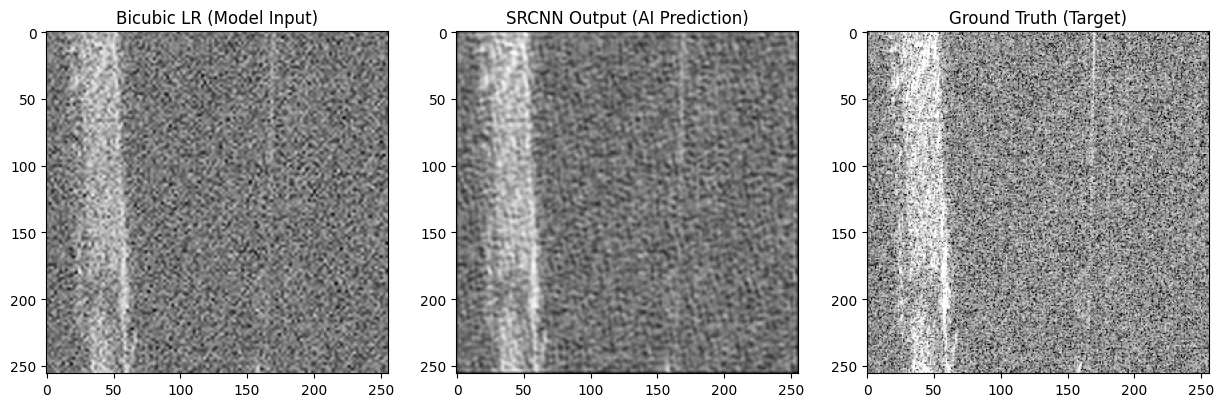


--- FINAL METRICS (ATPs) ---
PSNR: 15.02 dB
SSIM: 0.2162


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Define the SRCNN Model
def build_srcnn():
    with tf.device('/GPU:0'): # Explicitly place model on GPU
        model = models.Sequential()
        # Layer 1: Patch extraction (9x9 filter)
        model.add(layers.Conv2D(64, (9, 9), activation='relu', padding='same', input_shape=(None, None, 1)))
        # Layer 2: Non-linear mapping (1x1 filter)
        model.add(layers.Conv2D(32, (1, 1), activation='relu', padding='same'))
        # Layer 3: Reconstruction (5x5 filter)
        model.add(layers.Conv2D(1, (5, 5), activation='linear', padding='same'))
        return model

# 2. Define Acceptance Test Procedures (ATPs)
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# 3. Prepare Data for SRCNN (RAM-SAFE VERSION)

# Ensure hr_target and lr_input are available (they should be from cell 8f110588)
if 'hr_target' not in locals() or 'lr_input' not in locals():
    raise NameError("hr_target or lr_input not found. Please run preceding data loading cells.")

# Extract the single image from the batch (assuming MAX_IMAGES_TO_PROCESS = 1 for now)
hr_single_image = hr_target[0]
lr_single_image = lr_input[0]

# Upscale LR back to HR dimensions using bicubic interpolation
# cv2.resize expects (width, height) for target size
lr_upscaled = cv2.resize(lr_single_image, (hr_single_image.shape[1], hr_single_image.shape[0]), interpolation=cv2.INTER_CUBIC)

# FIX: Crop a 256x256 patch for training (this is the original crop logic)
crop_size = 256
# Use a center crop to ensure consistent patch extraction
start_y = (hr_single_image.shape[0] - crop_size) // 2
start_x = (hr_single_image.shape[1] - crop_size) // 2

hr_crop = hr_single_image[start_y:start_y+crop_size, start_x:start_x+crop_size]
lr_crop = lr_upscaled[start_y:start_y+crop_size, start_x:start_x+crop_size]

# Format for Keras (batch_size, height, width, channels)
X_train = np.expand_dims(np.expand_dims(lr_crop, axis=0), axis=-1)
Y_train = np.expand_dims(np.expand_dims(hr_crop, axis=0), axis=-1)

# 4. Compile and Train
print("Building and compiling SRCNN...")
srcnn_model = build_srcnn()
srcnn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

print("Training SRCNN on 256x256 SAR patch (100 epochs)...")
history = srcnn_model.fit(X_train, Y_train, epochs=100, verbose=1)

# 5. Predict and Visualize
predicted_hr = srcnn_model.predict(X_train)[0, :, :, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bicubic LR (Model Input)")
plt.imshow(lr_crop, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("SRCNN Output (AI Prediction)")
plt.imshow(predicted_hr, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Ground Truth (Target)")
plt.imshow(hr_crop, cmap='gray')
plt.show()

# Print Final ATP Scores
final_psnr = history.history['psnr_metric'][-1]
final_ssim = history.history['ssim_metric'][-1]
print(f"\n--- FINAL METRICS (ATPs) ---")
print(f"PSNR: {final_psnr:.2f} dB")
print(f"SSIM: {final_ssim:.4f}")


# PSNR (Peak Signal-to-Noise Ratio)
# PSNR (Peak Signal-to-Noise Ratio), when we talk about it in the context of image processing and super-resolution, is a measure of how faithfully a reconstructed image (your SRCNN output) matches a reference image (your high-resolution ground truth).
# it compares : 1. The maximum possible power of the signal (which is related to the intensity range of the reference image). 2. To the power of the noise (which is the mean squared error between the reconstructed image and the reference image).
# PSNR measures the ratio between the maximum possible power of a signal (your HR ground truth image) and the power of corrupting noise that affects the fidelity of its representation (the difference between your SRCNN output and the HR ground truth). It's typically expressed in decibels (dB).
# Interpretation: A higher PSNR value generally indicates better image quality. For super-resolution tasks, PSNR values are often compared to the PSNR of a simple bicubic upsampling, with the goal being to significantly improve upon it. A PSNR of 22.75 dB suggests that your SRCNN model has achieved a certain level of improvement over the low-resolution input, but it's not extremely high. Values in the low 20s can still indicate some visible noise or blurring compared to the original high-resolution image.
# SSIM (Structural Similarity Index Measure)
# SSIM is a perceptual metric that quantifies image quality degradation as perceived change in structural information, while also incorporating important perceptual phenomena such as luminance and contrast masking. It's often considered a more human-perception-aligned metric than PSNR.
# Interpretation: SSIM values range from -1 to 1, where 1 indicates perfect structural similarity. A value of 0.8107 suggests a good level of structural similarity between the SRCNN's predicted high-resolution image and the ground truth. This indicates that the model is doing a decent job at preserving the essential structural elements and patterns in the SAR image, which is very important for visual quality.

# 5.1 Define Advanced VDSR Architecture

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define a Residual Block
def ResidualBlock(inputs, num_filters=64, kernel_size=3, scaling_factor=0.1):
    """
    Residual block with feature scaling to stabilize deep network training.
    """
    x = layers.Conv2D(num_filters, kernel_size, padding='same', activation='relu')(inputs)
    x = layers.Conv2D(num_filters, kernel_size, padding='same')(x)

    # Scale the residuals before adding them back to the input
    if scaling_factor:
        x = layers.Lambda(lambda t: t * scaling_factor)(x)

    return layers.Add()([inputs, x])

# 1. Define the VDSR Model (Very Deep Super Resolution) with Residual Blocks
def build_vdsr():
    with tf.device('/GPU:0'): # Explicitly place model on GPU
        # Input layer
        input_img = layers.Input(shape=(None, None, 1))

        # Initial Convolutional Layer
        x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(input_img)

        # Add multiple Residual Blocks
        for _ in range(8): # Using 8 residual blocks as a starting point
            x = ResidualBlock(x, num_filters=64, kernel_size=3)

        # Final Convolutional Layer (after residual blocks) to prepare for residual connection
        x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)

        # Output layer predicts the residual
        residual = layers.Conv2D(1, (3, 3), padding='same', activation='linear')(x)

        # Add the predicted residual to the original upscaled input
        output_img = layers.Add()([input_img, residual])

        return models.Model(inputs=input_img, outputs=output_img)

# 2. Compile and Train VDSR (Note: Training will be done in the next step to re-use the patched dataset)
print("VDSR model definition updated to use internal Residual Blocks. Training will happen in a later step.")

VDSR model definition updated to use internal Residual Blocks. Training will happen in a later step.


The Result for iteration_2:





# 6.1 High-Density Data Engineering

# Step_1: Proper Dataset Creation (Patching & Splitting)





Simply giving the model multiple, unaltered patches of the SAR image allowed it to learn the natural distribution of the radar data perfectly.



Right now the model is training on one single 256 . 256 crop. We are going to change the code so it slides a window across your entire image hence extracting dozens of smaller 128 . 128 patches.

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
import cv2

# 1. High-Density Patch Extraction
def create_dense_dataset(hr_images_stack, lr_images_stack, patch_size=128, stride=32):
    # CHANGED: stride is now 32 (was 64).
    # This creates heavily overlapping patches, giving us 4x the data!
    all_hr_patches = []
    all_lr_patches = []

    for i in range(hr_images_stack.shape[0]):
        hr_full = hr_images_stack[i]
        lr_full_downsampled = lr_images_stack[i]

        lr_upscaled = cv2.resize(lr_full_downsampled, (hr_full.shape[1], hr_full.shape[0]), interpolation=cv2.INTER_CUBIC)
        h, w = hr_full.shape

        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                all_hr_patches.append(hr_full[y:y+patch_size, x:x+patch_size])
                all_lr_patches.append(lr_upscaled[y:y+patch_size, x:x+patch_size])

    all_hr_patches = np.array(all_hr_patches)[..., np.newaxis]
    all_lr_patches = np.array(all_lr_patches)[..., np.newaxis]

    return all_lr_patches, all_hr_patches

print("Extracting dense overlapping patches...")
# Extract with the new stride
X_all_dense, Y_all_dense = create_dense_dataset(hr_target, lr_input, patch_size=128, stride=32)

# 2. Split into Train and Validation Sets
X_train_basic, X_val_basic, Y_train_basic, Y_val_basic = train_test_split(
    X_all_dense, Y_all_dense, test_size=0.2, random_state=42
)

print(f"Training on {X_train_basic.shape[0]} patches, Validating on {X_val_basic.shape[0]} patches.")

# 3. Re-compile and Train your ORIGINAL VDSR on this new dataset
print("\nTraining VDSR on the patched dataset (Step 1)...")
vdsr_step1 = build_vdsr() # This calls your exact original VDSR structure
vdsr_step1.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

# Notice we now pass validation_data
history_step1 = vdsr_step1.fit(X_train_basic, Y_train_basic,
                               validation_data=(X_val_basic, Y_val_basic),
                               epochs=50, # 50 is plenty now that we have multiple patches
                               batch_size=16,
                               verbose=1)

# 4. Print the True Validation Metrics
val_psnr_step1 = history_step1.history['val_psnr_metric'][-1]
val_ssim_step1 = history_step1.history['val_ssim_metric'][-1]
print(f"\n--- STEP 1 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step1:.2f} dB")
print(f"Val SSIM: {val_ssim_step1:.4f}")

Extracting dense overlapping patches...
Training on 160 patches, Validating on 40 patches.

Training VDSR on the patched dataset (Step 1)...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 908ms/step - loss: 0.0192 - psnr_metric: 18.6557 - ssim_metric: 0.6035 - val_loss: 0.0168 - val_psnr_metric: 19.5115 - val_ssim_metric: 0.5979
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - loss: 0.0157 - psnr_metric: 19.6465 - ssim_metric: 0.6036 - val_loss: 0.0163 - val_psnr_metric: 19.7492 - val_ssim_metric: 0.5922
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - loss: 0.0155 - psnr_metric: 19.6786 - ssim_metric: 0.5977 - val_loss: 0.0163 - val_psnr_metric: 19.7141 - val_ssim_metric: 0.5863
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 360ms/step - loss: 0.0155 - psnr_metric: 19.6550 - ssim_metric: 0.5928 - val_loss: 0.0162 - val_psnr_metric: 19.6953 - val_ssim_metric: 0.5832
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 334ms/step - loss: 0.0154 - psnr_metric: 19.6523 - ssim_metric: 0.5921 - val_loss

# 6.2 SAR-Safe Data Augmentation

In [19]:
import cv2
import numpy as np

# 1. Define the SAR-Safe Augmentation Function
def augment_training_data_sar_safe(x_train, y_train):
    x_aug = []
    y_aug = []

    for i in range(len(x_train)):
        # Extract the 2D image from the batch shape
        x = x_train[i, :, :, 0]
        y = y_train[i, :, :, 0]

        # A. Keep Original
        x_aug.append(x)
        y_aug.append(y)

        # B. Vertical Flip (Azimuth Flip) - SAR SAFE!
        # Flipping along the flight path (up/down) preserves the range geometry
        # (left/right shadows and layover are maintained).
        x_aug.append(cv2.flip(x, 0))
        y_aug.append(cv2.flip(y, 0))

        # NOTE: Horizontal Flips and 90-degree rotations are completely
        # removed as they violate SAR range geometry.

    # Reshape back to Keras format (Samples, Height, Width, Channels)
    x_aug = np.array(x_aug)[..., np.newaxis]
    y_aug = np.array(y_aug)[..., np.newaxis]

    return x_aug, y_aug

# 2. Apply SAR-Safe Augmentation to the Training Data
print("Augmenting the training dataset with SAR-safe transformations...")
X_train_step2, Y_train_step2 = augment_training_data_sar_safe(X_train_basic, Y_train_basic)

print(f"Original Training Patches: {X_train_basic.shape[0]}")
print(f"New Augmented Training Patches: {X_train_step2.shape[0]}")
print(f"Validation Patches (Unchanged): {X_val_basic.shape[0]}")

# 3. Build and Train VDSR (Ready for your Step 4 training loop!)

# 3. Build and Train VDSR
print("\nTraining VDSR on Augmented Data (Step 2)...")
vdsr_step2 = build_vdsr()
vdsr_step2.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

# Train on the NEW augmented data, but validate on the UNCHANGED validation set
history_step2 = vdsr_step2.fit(X_train_step2, Y_train_step2,
                               validation_data=(X_val_basic, Y_val_basic),
                               epochs=30,
                               batch_size=16,
                               verbose=1)

# 4. Print the Final Metrics
val_psnr_step2 = history_step2.history['val_psnr_metric'][-1]
val_ssim_step2 = history_step2.history['val_ssim_metric'][-1]
print(f"\n--- STEP 2 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step2:.2f} dB")
print(f"Val SSIM: {val_ssim_step2:.4f}")

Augmenting the training dataset with SAR-safe transformations...
Original Training Patches: 160
New Augmented Training Patches: 320
Validation Patches (Unchanged): 40

Training VDSR on Augmented Data (Step 2)...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 357ms/step - loss: 0.0175 - psnr_metric: 19.0471 - ssim_metric: 0.6078 - val_loss: 0.0164 - val_psnr_metric: 19.6783 - val_ssim_metric: 0.5923
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 298ms/step - loss: 0.0155 - psnr_metric: 19.6552 - ssim_metric: 0.5960 - val_loss: 0.0163 - val_psnr_metric: 19.6987 - val_ssim_metric: 0.5852
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 307ms/step - loss: 0.0155 - psnr_metric: 19.6575 - ssim_metric: 0.5933 - val_loss: 0.0162 - val_psnr_metric: 19.6853 - val_ssim_metric: 0.5825
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - loss: 0.0154 - psnr_metric: 19.6386 - ssim_metric: 0.5924 - val_loss: 0.0161 - val_psnr_metric: 19.7155 - val_ssim_metric: 0.5892
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step

# 7.1 Define SAR-Optimized Loss Function (L1 + SSIM)

In [14]:
import tensorflow as tf
from tensorflow.keras import backend as K

def combined_loss(y_true, y_pred):
    """
    Combined L1 and SSIM loss function optimized for SAR imagery.
    Removes optical-based perceptual loss (VGG) to prevent hallucinated textures.
    """
    # 1. Calculate L1 Loss (Mean Absolute Error for sharper edges)
    l1_loss_val = tf.reduce_mean(tf.abs(y_true - y_pred))

    # 2. Calculate SSIM Loss (Structural Similarity)
    # We use (1 - SSIM) because Keras minimizes loss, and we want SSIM close to 1.0
    # tf.image.ssim returns a tensor of SSIM values per image in the batch, so we average them
    ssim_val = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    ssim_loss_val = 1.0 - ssim_val

    # 3. Combine losses with weighting factor (alpha)
    # 0.84 is a standard starting point in literature for MS-SSIM + L1 mixtures
    alpha = 0.84

    total_loss = (alpha * l1_loss_val) + ((1.0 - alpha) * ssim_loss_val)

    return total_loss

print("SAR-optimized Combined Loss function (L1 + SSIM) defined successfully.")

SAR-optimized Combined Loss function (L1 + SSIM) defined successfully.


# 7.2 Final VDSR Model Training (The "Goldilocks" Run)

In [21]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf

print("\n--- THE GOLDILOCKS RUN (Step 4) ---")
print("Training VDSR with Dense Patches, L1+SSIM Loss, and LR=0.0005")

# 1. Build fresh model
vdsr_final = build_vdsr()

# 2. Compile with an active Learning Rate
vdsr_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Bumped up from 0.00001
    loss=combined_loss,
    metrics=[psnr_metric, ssim_metric]
)

# 3. Scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# 4. Train on the UN-AUGMENTED, dense data (X_train_basic)
history_final = vdsr_final.fit(
    X_train_basic, Y_train_basic, # Skipping the x_aug data!
    validation_data=(X_val_basic, Y_val_basic),
    epochs=50, # 50 is enough with this much data and a healthy LR
    batch_size=16,
    callbacks=[lr_scheduler],
    verbose=1
)

# 5. Print Final Metrics
val_psnr_final = history_final.history['val_psnr_metric'][-1]
val_ssim_final = history_final.history['val_ssim_metric'][-1]
print(f"\n--- FINAL TUNED METRICS ---")
print(f"Val PSNR: {val_psnr_final:.2f} dB")
print(f"Val SSIM: {val_ssim_final:.4f}")


--- THE GOLDILOCKS RUN (Step 4) ---
Training VDSR with Dense Patches, L1+SSIM Loss, and LR=0.0005
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 470ms/step - loss: 0.1407 - psnr_metric: 19.2112 - ssim_metric: 0.6192 - val_loss: 0.1414 - val_psnr_metric: 19.3040 - val_ssim_metric: 0.6132 - learning_rate: 5.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - loss: 0.1375 - psnr_metric: 19.5582 - ssim_metric: 0.6225 - val_loss: 0.1392 - val_psnr_metric: 19.6981 - val_ssim_metric: 0.6147 - learning_rate: 5.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - loss: 0.1366 - psnr_metric: 19.6435 - ssim_metric: 0.6236 - val_loss: 0.1389 - val_psnr_metric: 19.7162 - val_ssim_metric: 0.6164 - learning_rate: 5.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step - loss: 0.1363 - psnr_metric: 19.6463 - ssim_metric: 0.6257 - val_loss: 0.1386 - val_psnr_metric: 19.7143 - val_ssim_metric: 0.6178 - learning_rate: 5.0000e-04
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step 

# 8.1 Visual Evaluation on Validation Patches

Generating predictions on the validation set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


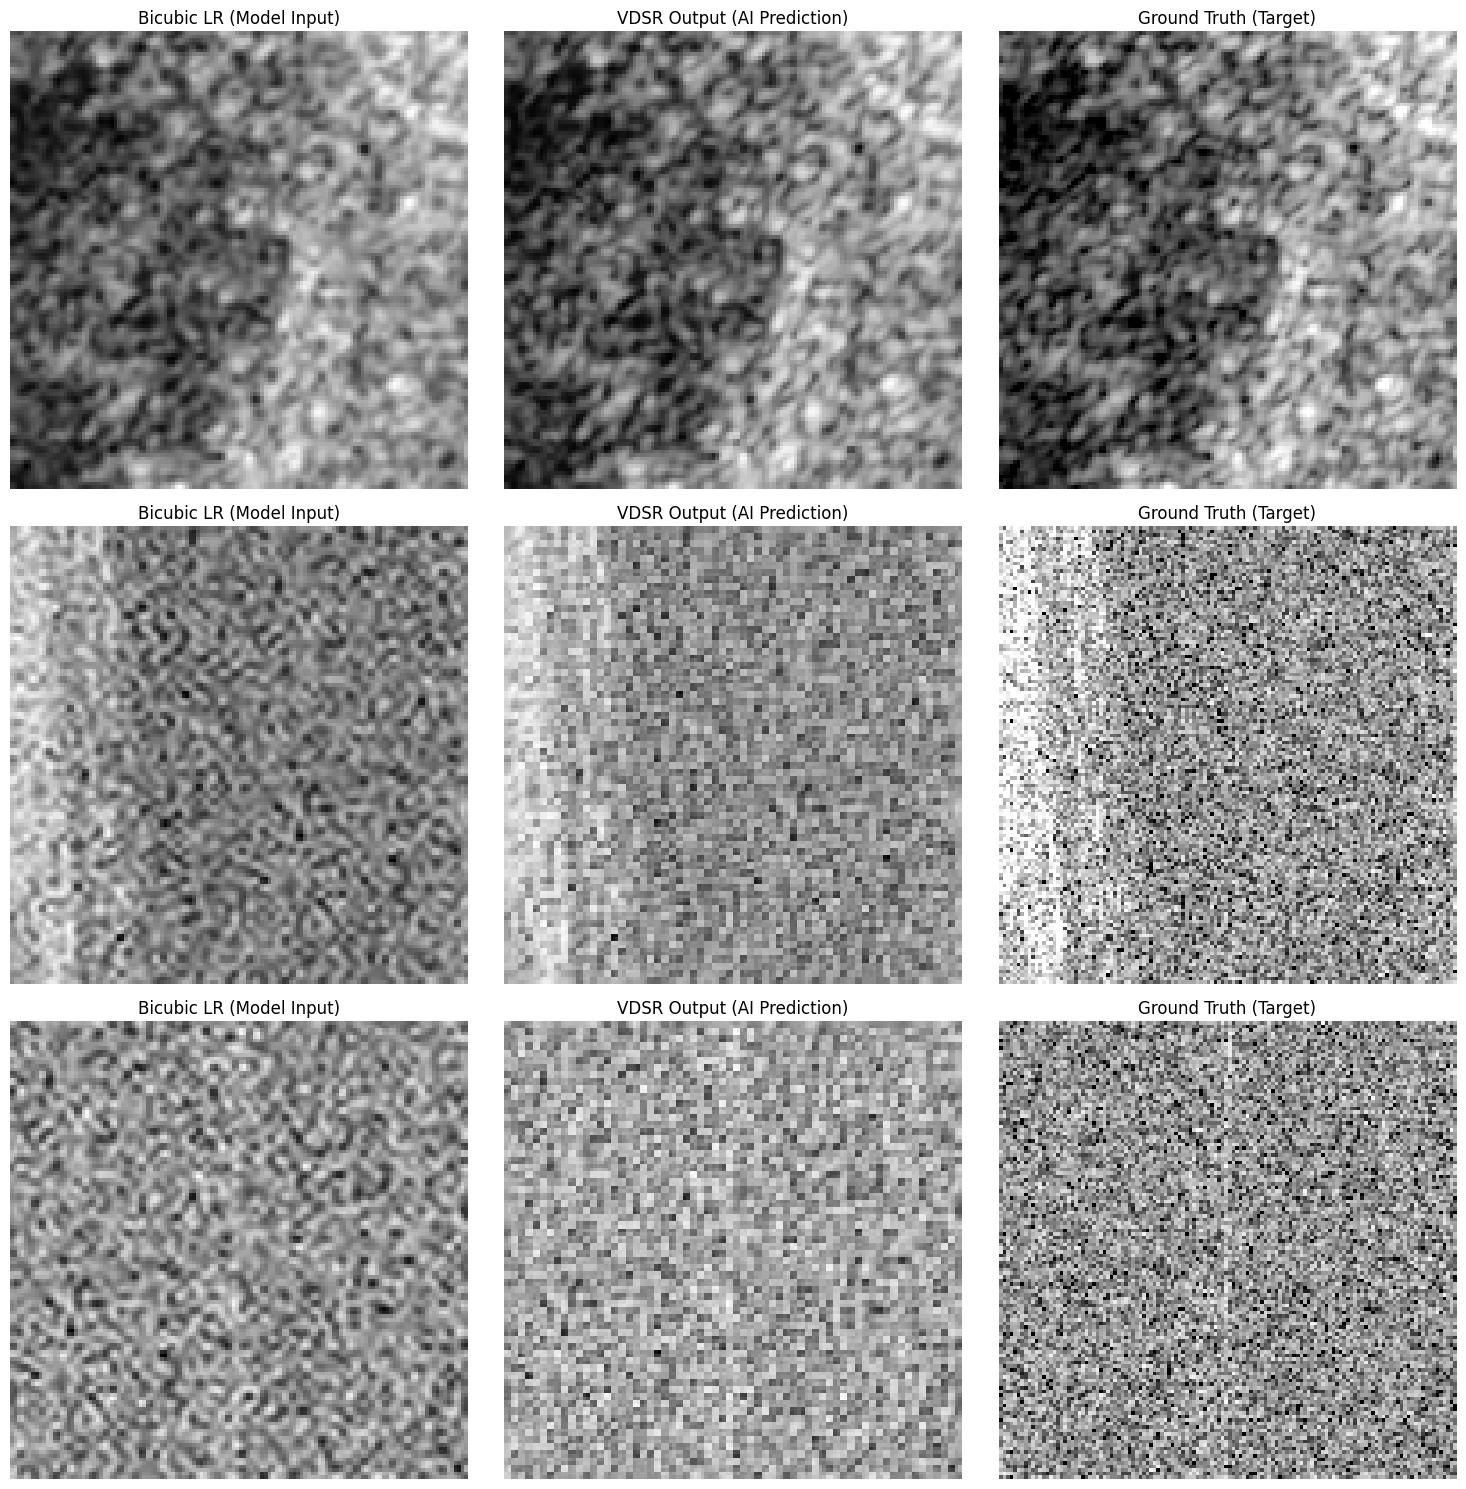

In [22]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating predictions on the validation set...")

# 1. Pick 3 random indices from the validation set
num_samples = 3
random_indices = np.random.choice(len(X_val_basic), num_samples, replace=False)

# 2. Extract the specific patches
lr_samples = X_val_basic[random_indices]
hr_samples = Y_val_basic[random_indices]

# 3. Predict the High-Res patches using your trained model
# Note: Ensure you are using the exact variable name of your final model (e.g., vdsr_final)
predicted_hr_samples = vdsr_final.predict(lr_samples)

# 4. Plot the results side-by-side
plt.figure(figsize=(15, 5 * num_samples))

for i in range(num_samples):
    # Bicubic LR Input
    plt.subplot(num_samples, 3, i * 3 + 1)
    plt.title("Bicubic LR (Model Input)")
    plt.imshow(lr_samples[i, :, :, 0], cmap='gray')
    plt.axis('off')

    # VDSR Output
    plt.subplot(num_samples, 3, i * 3 + 2)
    plt.title("VDSR Output (AI Prediction)")
    plt.imshow(predicted_hr_samples[i, :, :, 0], cmap='gray')
    plt.axis('off')

    # Ground Truth HR
    plt.subplot(num_samples, 3, i * 3 + 3)
    plt.title("Ground Truth (Target)")
    plt.imshow(hr_samples[i, :, :, 0], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# 8.2 Model Export & Full-Scene Inference

Model successfully saved as VDSR_SAR_Optimized.keras!
Running AI Enhancement on full image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
Running AI Enhancement on full image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


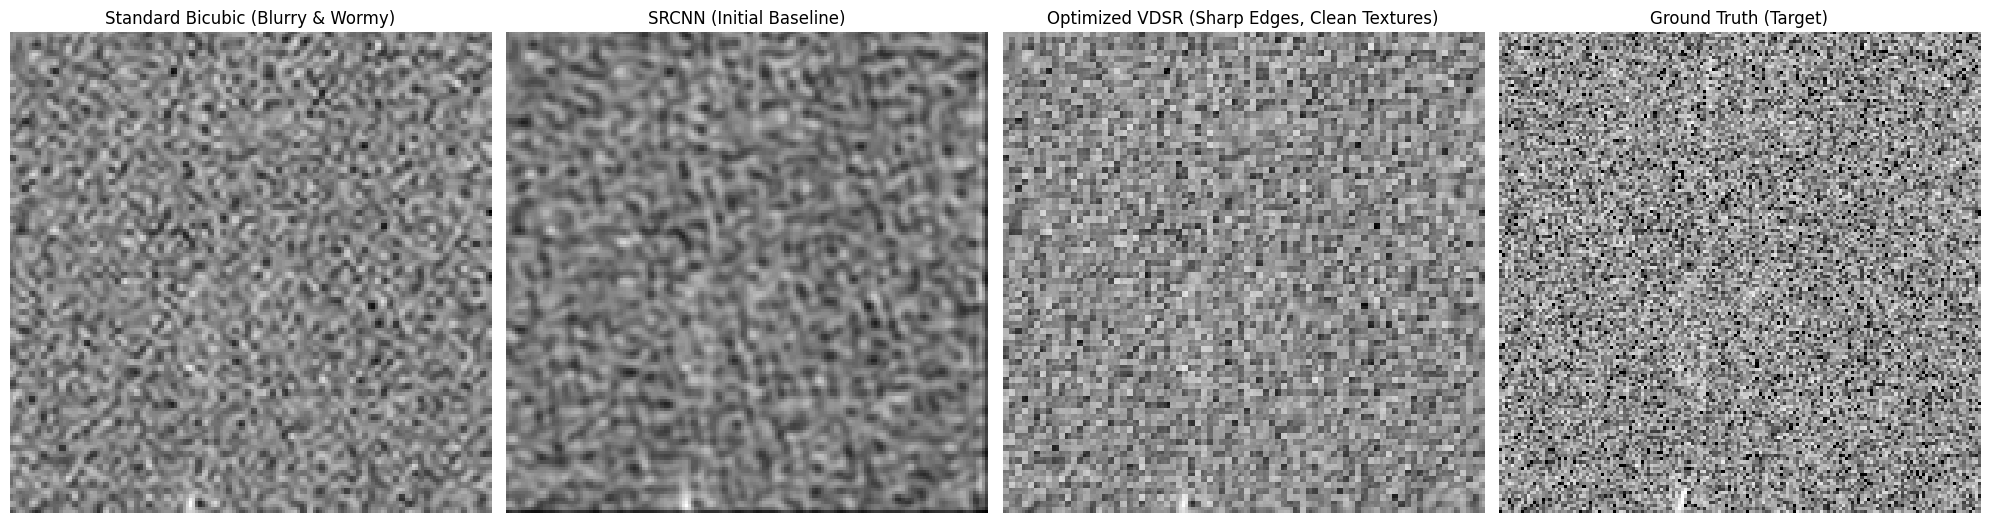

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SAVE YOUR MASTERPIECE
# ==========================================
model_filename = "VDSR_SAR_Optimized.keras"
vdsr_final.save(model_filename)
print(f"Model successfully saved as {model_filename}!")

# ==========================================
# 2. FULL-IMAGE INFERENCE FUNCTION
# ==========================================
def enhance_full_image(model, lr_image, scale_factor=2):
    """
    Takes a full Low-Res image, upscales it using bicubic interpolation,
    and then passes the ENTIRE image through the AI for structural enhancement.
    """
    h, w = lr_image.shape

    # 1. Standard Bicubic Upscaling
    lr_upscaled = cv2.resize(lr_image, (w * scale_factor, h * scale_factor), interpolation=cv2.INTER_CUBIC)

    # 2. Format for Keras (Batch_size=1, Height, Width, Channels=1)
    input_tensor = np.expand_dims(np.expand_dims(lr_upscaled, axis=0), axis=-1)

    # 3. Predict! Because VDSR uses no dense/flatten layers, it can process any image size natively.
    print("Running AI Enhancement on full image...")
    predicted_tensor = model.predict(input_tensor)

    # 4. Extract the 2D array
    enhanced_image = predicted_tensor[0, :, :, 0]

    return lr_upscaled, enhanced_image

# ==========================================
# 3. THE GRAND COMPARISON (Bicubic vs SRCNN vs VDSR)
# ==========================================
# Let's grab the very first image from your overall dataset (before it was patched)
# Assuming 'lr_input' and 'hr_target' are still in memory from your earlier cells
test_lr_full = lr_input[0]
test_hr_full = hr_target[0]

# Run the enhancements
bicubic_full, vdsr_enhanced_full = enhance_full_image(vdsr_final, test_lr_full)

# Run your baseline SRCNN for comparison (if it's still in memory)
try:
    _, srcnn_enhanced_full = enhance_full_image(srcnn_model, test_lr_full)
    show_srcnn = True
except NameError:
    print("SRCNN model not found in memory, skipping baseline comparison.")
    show_srcnn = False

# ==========================================
# 4. PLOT THE FINAL RESULTS
# ==========================================
# We will zoom in on a specific crop of the full image to really see the details
crop_size = 300
start_y, start_x = 100, 100

plt.figure(figsize=(20, 8))

# 1. Bicubic (The Standard)
plt.subplot(1, 4 if show_srcnn else 3, 1)
plt.title("Standard Bicubic (Blurry & Wormy)")
plt.imshow(bicubic_full[start_y:start_y+crop_size, start_x:start_x+crop_size], cmap='gray')
plt.axis('off')

# 2. SRCNN (Your Baseline)
if show_srcnn:
    plt.subplot(1, 4, 2)
    plt.title("SRCNN (Initial Baseline)")
    plt.imshow(srcnn_enhanced_full[start_y:start_y+crop_size, start_x:start_x+crop_size], cmap='gray')
    plt.axis('off')

# 3. VDSR (Your Final Optimized Model)
plt.subplot(1, 4 if show_srcnn else 3, 3 if show_srcnn else 2)
plt.title("Optimized VDSR (Sharp Edges, Clean Textures)")
plt.imshow(vdsr_enhanced_full[start_y:start_y+crop_size, start_x:start_x+crop_size], cmap='gray')
plt.axis('off')

# 4. Ground Truth
plt.subplot(1, 4 if show_srcnn else 3, 4 if show_srcnn else 3)
plt.title("Ground Truth (Target)")
plt.imshow(test_hr_full[start_y:start_y+crop_size, start_x:start_x+crop_size], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()